# Función Lapsus

$$B(r) = 1 - \frac{2M}{r} + \frac{Q^2}{r^2} - \gamma r$$

## Horizontes

$$\varphi \equiv \frac{\arccos[\Xi(M,Q,\gamma)]}{3}, 
\qquad \chi \equiv \frac{2\sqrt{1-6M\gamma}}{3\gamma}$$

$$r_{HH} = \frac{1}{3\gamma} + \chi\cos\varphi$$

$$r_H = \frac{1}{3\gamma} + \frac{\chi}{2}\left(\sqrt{3}\sin\varphi - \cos\varphi\right)$$

$$r_C = \frac{1}{3\gamma} - \frac{\chi}{2}\left(\cos\varphi + \sqrt{3}\sin\varphi\right)$$


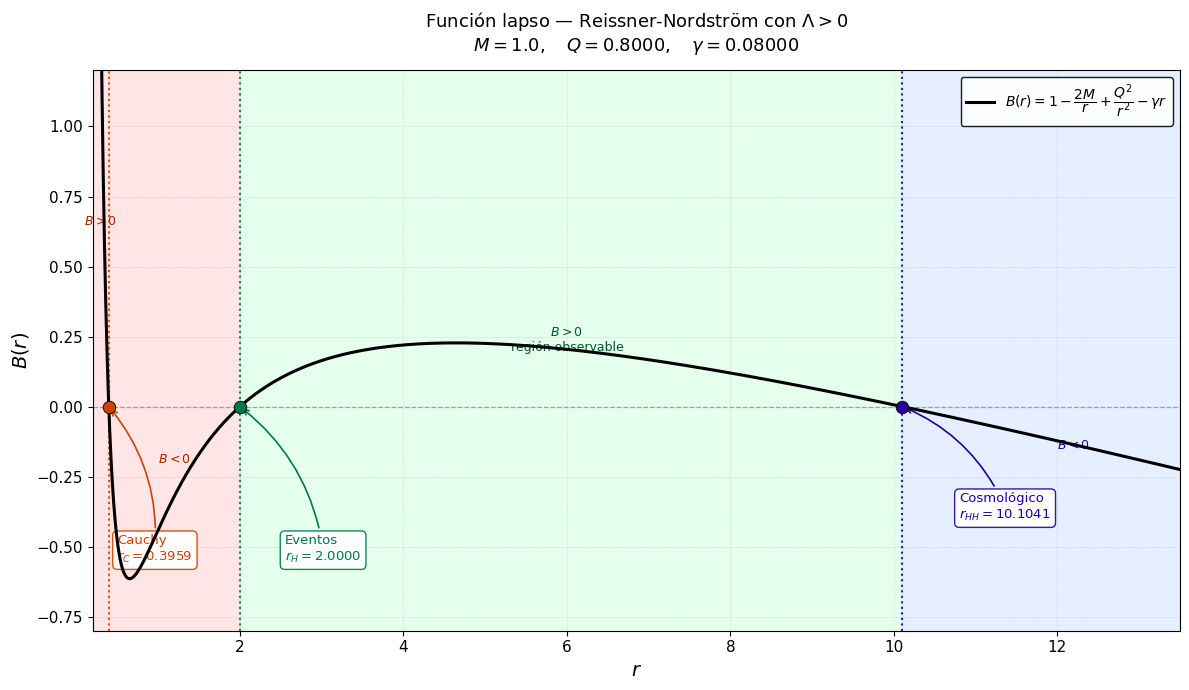

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ─── Parámetros ──────────────────────────────────────────────────────────────
def sistema(params):
    Q, g = params
    r1, r3 = 0.395878, 10.1041
    B = lambda r: 1 - 2/r + Q**2/r**2 - g*r
    return [B(r1), B(r3)]

Q0, g0 = fsolve(sistema, [0.8, 0.01])
M, Q, g = 1.0, Q0, g0

# ─── Horizontes analíticos ───────────────────────────────────────────────────
chi = 2*np.sqrt(1 - 6*M*g) / (3*g)
Xi  = (2 - 18*M*g + 27*Q**2*g**2) / (2*(1 - 6*M*g)**1.5)
phi = np.arccos(Xi) / 3

r_HH = 1/(3*g) + chi * np.cos(phi)                                # n=0
r_H  = 1/(3*g) + chi/2 * (np.sqrt(3)*np.sin(phi) - np.cos(phi))  # n=2
r_C  = 1/(3*g) - chi/2 * (np.cos(phi) + np.sqrt(3)*np.sin(phi))  # n=1

# ─── Dominio ─────────────────────────────────────────────────────────────────
r  = np.linspace(0.20, 13.5, 10000)
def B(r): return 1 - 2*M/r + Q**2/r**2 - g*r
Br = B(r)

# ─── Figura fondo blanco ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Regiones sombreadas ───────────────────────────────────────────────────────
regions = [
    (0.20,  r_C,  '#ffcccc', 0.5),   # B > 0 interior
    (r_C,   r_H,  '#ffcccc', 0.5),   # B < 0
    (r_H,   r_HH, '#ccffdd', 0.5),   # B > 0 observable
    (r_HH,  13.5, '#cce0ff', 0.5),   # B < 0 cosmológico
]
for x0, x1, color, alpha in regions:
    ax.axvspan(x0, x1, alpha=alpha, color=color)

# ── Línea cero ────────────────────────────────────────────────────────────────
ax.axhline(0, color='gray', linewidth=0.9, linestyle='--', alpha=0.7)

# ── Curva B(r) ────────────────────────────────────────────────────────────────
ax.plot(r, Br, color='black', linewidth=2.2, zorder=5,
        label=r'$B(r) = 1 - \dfrac{2M}{r} + \dfrac{Q^2}{r^2} - \gamma r$')

# ── Horizontes ────────────────────────────────────────────────────────────────
horizontes = [
    (r_C,  '#cc4400', 'Cauchy\n$r_C={:.4f}$'.format(r_C),              ( 0.50, -0.55)),
    (r_H,  '#007744', 'Eventos\n$r_H={:.4f}$'.format(r_H),             ( 2.55, -0.55)),
    (r_HH, '#220099', 'Cosmológico\n$r_{{HH}}={:.4f}$'.format(r_HH),   (10.80, -0.40)),
]
for r_val, color, etiqueta, pos_text in horizontes:
    ax.axvline(r_val, color=color, linewidth=1.5, linestyle=':', alpha=0.9, zorder=4)
    ax.plot(r_val, 0, 'o', color=color, markersize=9, zorder=7,
            markeredgecolor='black', markeredgewidth=0.6)
    ax.annotate(
        etiqueta,
        xy=(r_val, 0),
        xytext=pos_text,
        color=color,
        fontsize=9.5,
        ha='left',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2,
                        connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=color, alpha=0.9)
    )

# ── Texto de regiones ─────────────────────────────────────────────────────────
ax.text(0.30,   0.65, '$B>0$',                   color='#aa2200', fontsize=9, ha='center')
ax.text(1.20,  -0.20, '$B<0$',                   color='#aa2200', fontsize=9, ha='center')
ax.text(6.00,   0.20, '$B>0$\nregión observable', color='#005533', fontsize=9, ha='center')
ax.text(12.20, -0.15, '$B<0$',                   color='#220099', fontsize=9, ha='center')

# ── Ejes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(0.20, 13.5)
ax.set_ylim(-0.80, 1.20)
ax.set_xlabel(r'$r$',    fontsize=14, color='black')
ax.set_ylabel(r'$B(r)$', fontsize=14, color='black')
ax.tick_params(colors='black', labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(
    r'Función lapso — Reissner-Nordström con $\Lambda > 0$' + '\n'
    + r'$M=%.1f,\quad Q=%.4f,\quad \gamma=%.5f$' % (M, Q, g),
    fontsize=13, pad=14, color='black'
)

# ── Leyenda ───────────────────────────────────────────────────────────────────
ax.legend(loc='upper right', fontsize=10,
          facecolor='white', edgecolor='black', framealpha=0.9)

ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='gray')

plt.tight_layout()
plt.savefig('lapso_RN.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

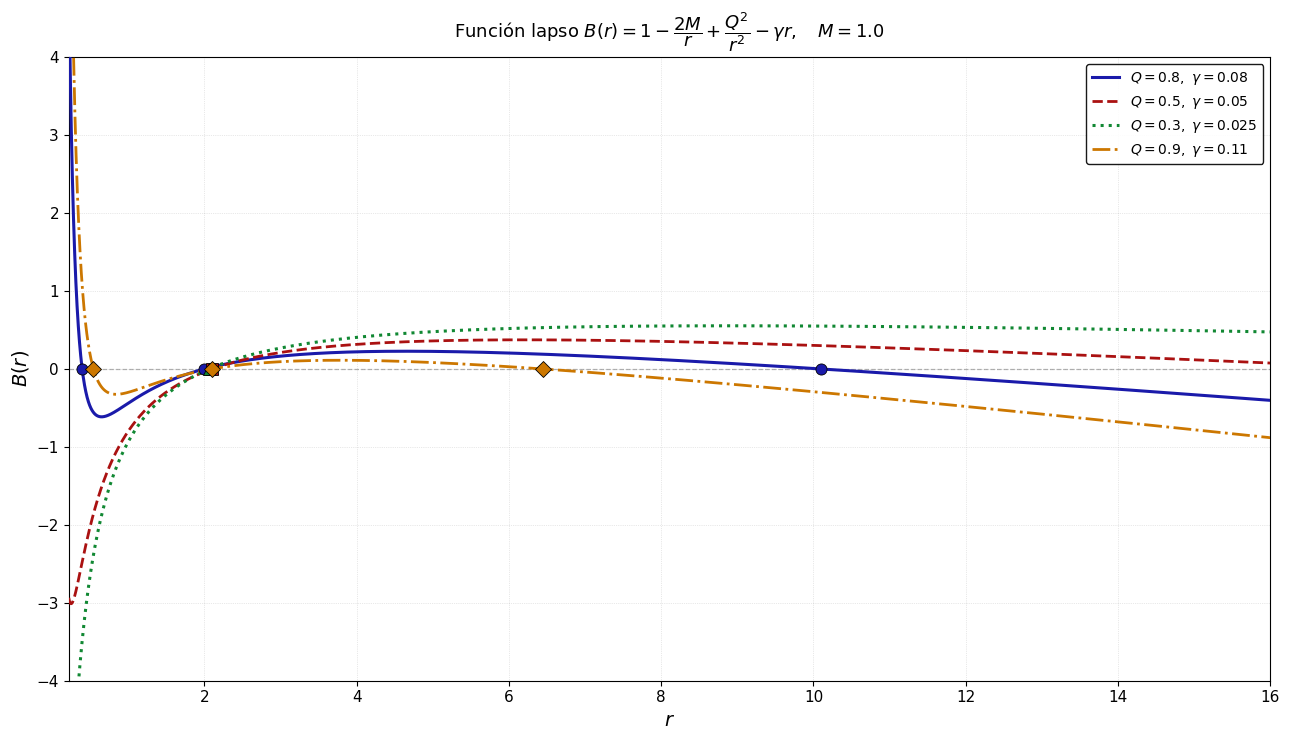

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Función lapso ────────────────────────────────────────────────────────────
def B(r, M, Q, g):
    return 1 - 2*M/r + Q**2/r**2 - g*r

# ─── Horizontes analíticos ────────────────────────────────────────────────────
def horizontes(M, Q, g):
    discriminante = 1 - 6*M*g
    if discriminante <= 0:
        return None, None, None
    chi = 2*np.sqrt(discriminante) / (3*g)
    Xi  = (2 - 18*M*g + 27*Q**2*g**2) / (2*discriminante**1.5)
    if abs(Xi) > 1:
        return None, None, None
    phi  = np.arccos(Xi) / 3
    r_HH = 1/(3*g) + chi * np.cos(phi)
    r_H  = 1/(3*g) + chi/2 * (np.sqrt(3)*np.sin(phi) - np.cos(phi))
    r_C  = 1/(3*g) - chi/2 * (np.cos(phi) + np.sqrt(3)*np.sin(phi))
    return r_C, r_H, r_HH

# ─── Casos ────────────────────────────────────────────────────────────────────
M = 1.0
casos = [
    {'Q': 0.80, 'g': 0.080, 'color': '#1a1aaa', 'ls': '-',  'lw': 2.2},
    {'Q': 0.50, 'g': 0.050, 'color': '#aa1111', 'ls': '--', 'lw': 2.0},
    {'Q': 0.30, 'g': 0.025, 'color': '#118833', 'ls': ':',  'lw': 2.2},
    {'Q': 0.90, 'g': 0.110, 'color': '#cc7700', 'ls': '-.', 'lw': 2.0},
]

# ─── Dominio ──────────────────────────────────────────────────────────────────
r = np.linspace(0.22, 16.0, 12000)

# ─── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Línea cero ────────────────────────────────────────────────────────────────
ax.axhline(0, color='gray', linewidth=0.9, linestyle='--', alpha=0.6)

# ── Curvas y marcadores en horizontes ─────────────────────────────────────────
marker_styles = ['o', 's', '^', 'D']

for i, caso in enumerate(casos):
    Q, g, color, ls, lw = caso['Q'], caso['g'], caso['color'], caso['ls'], caso['lw']

    Br    = B(r, M, Q, g)
    label = r'$Q={},\ \gamma={}$'.format(Q, g)
    ax.plot(r, Br, color=color, linewidth=lw, linestyle=ls, label=label, zorder=5)

    r_C, r_H, r_HH = horizontes(M, Q, g)
    if r_C is None:
        continue

    mk = marker_styles[i]
    for r_val in [r_C, r_H, r_HH]:
        ax.plot(r_val, 0, marker=mk, color=color, markersize=8, zorder=7,
                markeredgecolor='black', markeredgewidth=0.6)

# ── Ejes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(0.22, 16.0)
ax.set_ylim(-4.0, 4.0)
ax.set_xlabel(r'$r$',    fontsize=14)
ax.set_ylabel(r'$B(r)$', fontsize=14)
ax.tick_params(labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(
    r'Función lapso $B(r) = 1 - \dfrac{2M}{r} + \dfrac{Q^2}{r^2} - \gamma r$'
    + f'$,\quad M={M}$',
    fontsize=13, pad=14
)

# ── Leyenda ───────────────────────────────────────────────────────────────────
ax.legend(loc='upper right', fontsize=10,
          facecolor='white', edgecolor='black', framealpha=0.9)

ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.35, color='gray')

plt.tight_layout()
plt.savefig('lapso_RN_multicurva.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

# Agujeros Negros Extremos

## Caso 1 $r_C=r_H=r_{HH}$

## Caso 2 $r_H=r_{HH}$

## Caso 3 $r_C=r_H$



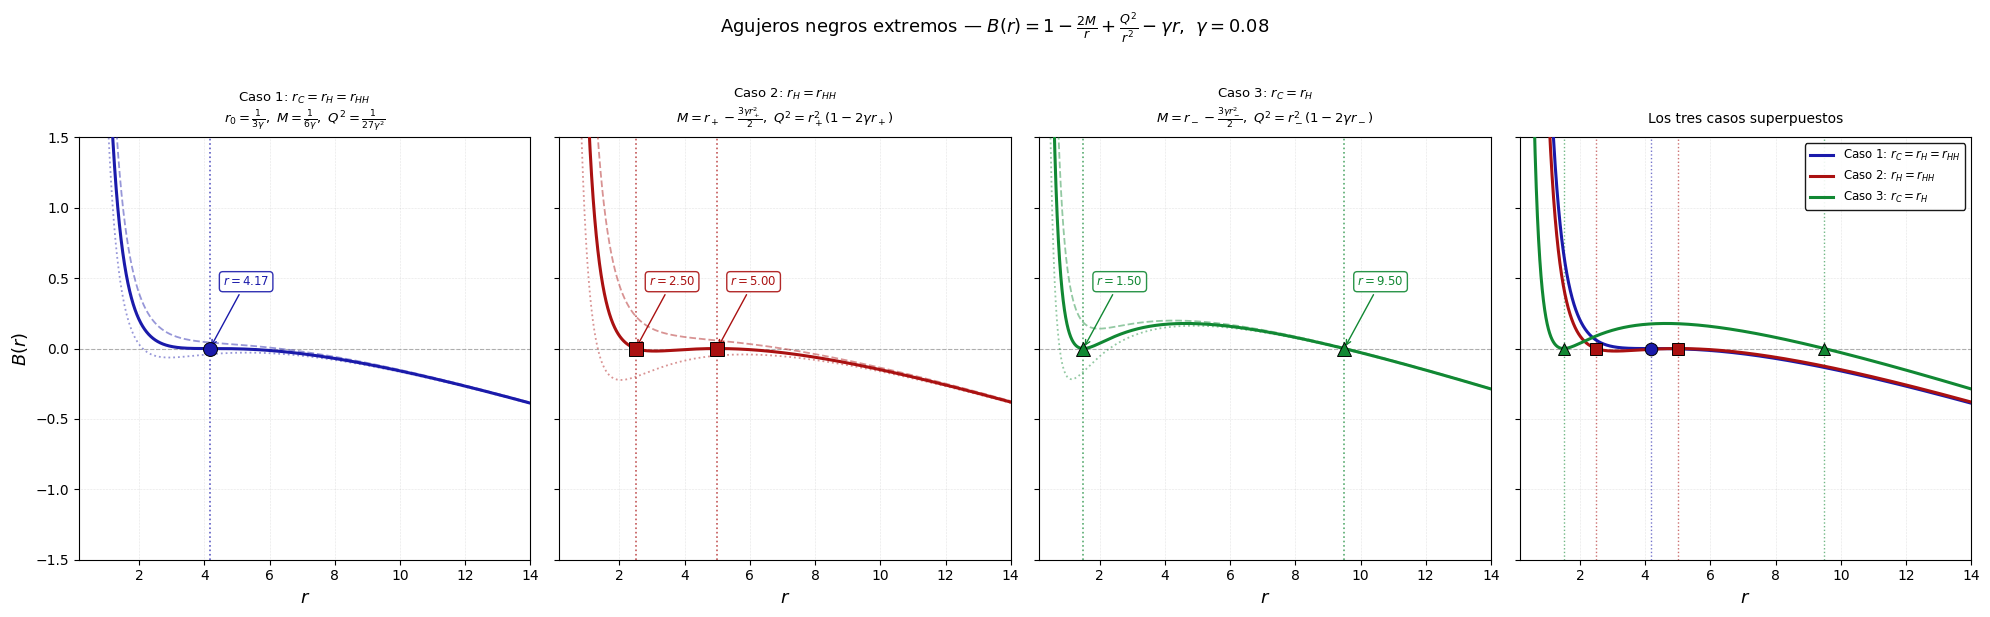

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def B(r, M, Q, g):
    return 1 - 2*M/r + Q**2/r**2 - g*r

r = np.linspace(0.15, 14.0, 12000)

fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
fig.patch.set_facecolor('white')

g = 0.080

# ─── Parámetros de cada caso ──────────────────────────────────────────────────
# Caso 1: tres iguales
r0 = 1/(3*g)
M1 = 1/(6*g)
Q1 = 1/np.sqrt(27*g**2)

# Caso 2: r_H = r_HH
r2p  = 5.0
r2C  = 1/g - 2*r2p
M2   = r2p - 1.5*g*r2p**2
Q2   = np.sqrt(r2p**2*(1 - 2*g*r2p))

# Caso 3: r_C = r_H
r3m  = 1.5
r3HH = 1/g - 2*r3m
M3   = r3m - 1.5*g*r3m**2
Q3   = np.sqrt(r3m**2*(1 - 2*g*r3m))

casos = [
    {'M': M1, 'Q': Q1, 'r_doble': [r0],        'label': 'Caso 1: $r_C=r_H=r_{HH}$', 'color': '#1a1aaa'},
    {'M': M2, 'Q': Q2, 'r_doble': [r2C, r2p],  'label': 'Caso 2: $r_H=r_{HH}$',     'color': '#aa1111'},
    {'M': M3, 'Q': Q3, 'r_doble': [r3m, r3HH], 'label': 'Caso 3: $r_C=r_H$',        'color': '#118833'},
]

marker_styles = ['o', 's', '^']

titulos = [
    'Caso 1: $r_C = r_H = r_{HH}$\n' + r'$r_0=\frac{1}{3\gamma},\ M=\frac{1}{6\gamma},\ Q^2=\frac{1}{27\gamma^2}$',
    'Caso 2: $r_H = r_{HH}$\n'        + r'$M=r_+ - \frac{3\gamma r_+^2}{2},\ Q^2=r_+^2(1-2\gamma r_+)$',
    'Caso 3: $r_C = r_H$\n'           + r'$M=r_- - \frac{3\gamma r_-^2}{2},\ Q^2=r_-^2(1-2\gamma r_-)$',
]
dQs = [0.15, 0.30, 0.15]

# ══════════════════════════════════════════════════════════════════════════════
# Paneles individuales (casos 1, 2, 3)
# ══════════════════════════════════════════════════════════════════════════════
for i, (caso, titulo, dQ) in enumerate(zip(casos, titulos, dQs)):
    ax = axes[i]
    ax.set_facecolor('white')
    color = caso['color']
    M_, Q_ = caso['M'], caso['Q']

    # Curva extrema
    ax.plot(r, B(r, M_, Q_, g), color=color, linewidth=2.2, zorder=5)

    # Perturbaciones (Q ± dQ para mostrar separación de raíces)
    for delta, ls in [(dQ, '--'), (-dQ, ':')]:
        ax.plot(r, B(r, M_, Q_+delta, g), color=color, linewidth=1.3,
                linestyle=ls, alpha=0.45, zorder=4)

    # Línea cero
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

    # Marcadores en horizontes
    for r_val in caso['r_doble']:
        ax.axvline(r_val, color=color, linewidth=1.2, linestyle=':', alpha=0.7)
        ax.plot(r_val, 0, marker=marker_styles[i], color=color, markersize=10,
                zorder=7, markeredgecolor='black', markeredgewidth=0.7)
        ax.annotate(f'$r={r_val:.2f}$',
                    xy=(r_val, 0), xytext=(r_val+0.4, 0.45),
                    fontsize=8.5, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor=color, alpha=0.9))

    ax.set_title(titulo, fontsize=9.5, pad=10)
    ax.set_xlim(0.15, 14.0)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel(r'$r$', fontsize=13)
    if i == 0:
        ax.set_ylabel(r'$B(r)$', fontsize=13)
    ax.grid(True, linestyle=':', linewidth=0.4, alpha=0.4, color='gray')
    ax.tick_params(labelsize=10)

# ══════════════════════════════════════════════════════════════════════════════
# Panel 4: las tres curvas superpuestas
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[3]
ax.set_facecolor('white')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

for i, caso in enumerate(casos):
    color = caso['color']
    M_, Q_ = caso['M'], caso['Q']

    ax.plot(r, B(r, M_, Q_, g), color=color, linewidth=2.2,
            label=caso['label'], zorder=5)

    for r_val in caso['r_doble']:
        ax.axvline(r_val, color=color, linewidth=1.0, linestyle=':', alpha=0.6)
        ax.plot(r_val, 0, marker=marker_styles[i], color=color, markersize=9,
                zorder=7, markeredgecolor='black', markeredgewidth=0.7)

ax.set_title('Los tres casos superpuestos', fontsize=10, pad=10)
ax.set_xlim(0.15, 14.0)
ax.set_xlabel(r'$r$', fontsize=13)
ax.legend(loc='upper right', fontsize=8.5, facecolor='white',
          edgecolor='black', framealpha=0.9)
ax.grid(True, linestyle=':', linewidth=0.4, alpha=0.4, color='gray')
ax.tick_params(labelsize=10)

# ─── Título general ───────────────────────────────────────────────────────────
fig.suptitle(
    r'Agujeros negros extremos — $B(r) = 1 - \frac{2M}{r} + \frac{Q^2}{r^2} - \gamma r$'
    + f',  $\\gamma = {g}$',
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig('extremos_RN_v2.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

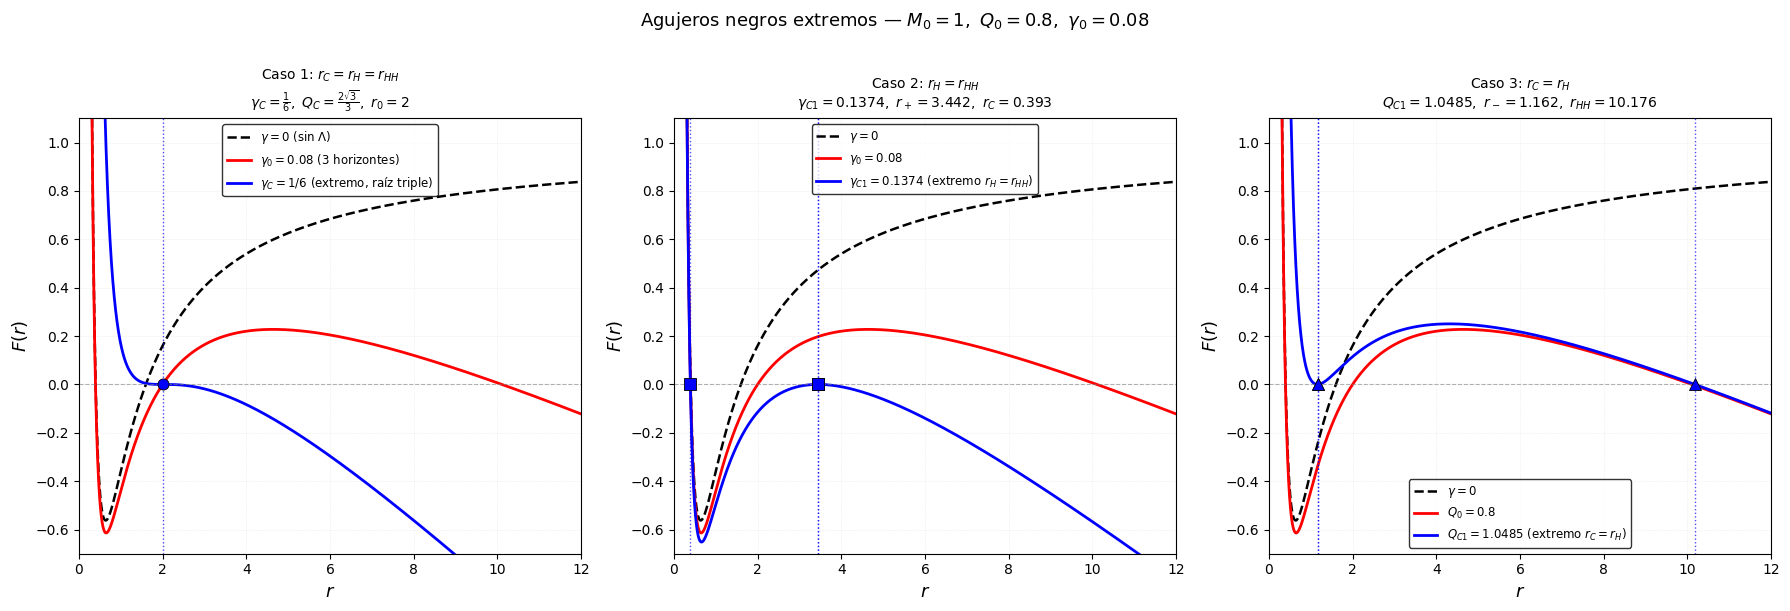

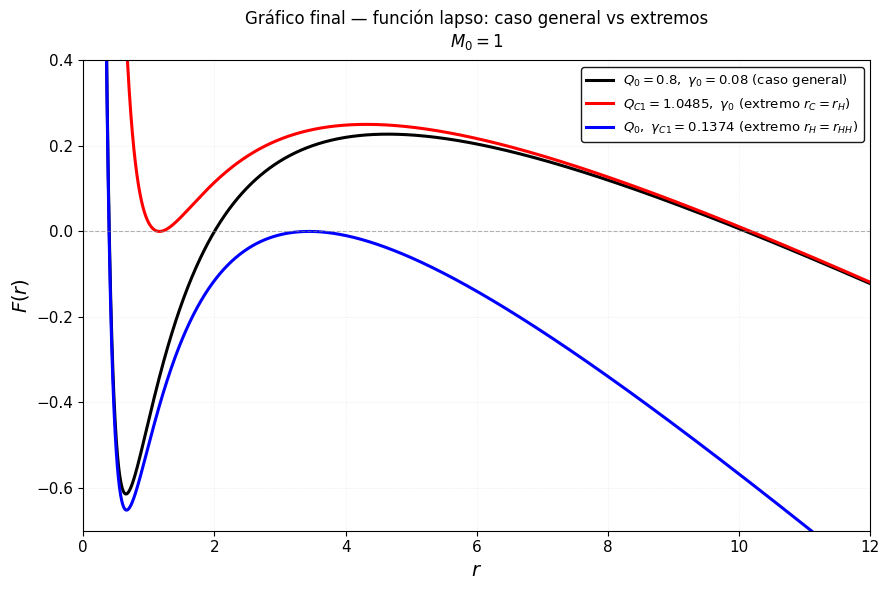

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ─── Parámetros base ──────────────────────────────────────────────────────────
M0 = 1.0
Q0 = 0.8
g0 = 0.08

# ─── Función lapso ────────────────────────────────────────────────────────────
def B(r, M, Q, g):
    return 1 - 2*M/r + Q**2/r**2 - g*r

# ─── Discriminante ────────────────────────────────────────────────────────────
def Delta(M, Q, g):
    return (-108*M**2 + 108*Q**2
            + (864*M**3 - 972*M*Q**2)*g
            + 729*Q**4*g**2)

# ─── Caso 1: tres iguales ─────────────────────────────────────────────────────
gC  = 1/6
QC  = 2*np.sqrt(3)/3
rC1 = 1/(3*gC)       # = 2

# ─── Caso 2: r_H = r_HH ──────────────────────────────────────────────────────
# Resolver Delta(M0, Q0, gamma) = 0 para gamma
gC1     = fsolve(lambda g: Delta(M0, Q0, g[0]), [0.13])[0]
rdob2   = np.sort(np.real(np.roots([-gC1, 1, -2*M0, Q0**2])))

# ─── Caso 3: r_C = r_H ───────────────────────────────────────────────────────
# Resolver Delta(M0, Q, g0) = 0 para Q
QC1     = fsolve(lambda Q: Delta(M0, Q[0], g0), [1.0])[0]
rdob3   = np.sort(np.real(np.roots([-g0, 1, -2*M0, QC1**2])))

# ─── Dominio ──────────────────────────────────────────────────────────────────
r = np.linspace(0.15, 12.0, 10000)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 1: tres paneles individuales
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

# ── Panel 1: Caso 1 ───────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.plot(r, B(r, M0, Q0, 0),   color='black', lw=1.8, ls='--',
        label=r'$\gamma=0$ (sin $\Lambda$)')
ax.plot(r, B(r, M0, Q0, g0),  color='red',   lw=2.0,
        label=r'$\gamma_0=0.08$ (3 horizontes)')
ax.plot(r, B(r, M0, QC,  gC), color='blue',  lw=2.0,
        label=r'$\gamma_C=1/6$ (extremo, raíz triple)')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.axvline(rC1, color='blue', lw=1.0, ls=':', alpha=0.7)
ax.plot(rC1, 0, 'o', color='blue', ms=8, zorder=6,
        markeredgecolor='black', markeredgewidth=0.6)
ax.set_xlim(0, 12); ax.set_ylim(-0.7, 1.1)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('$F(r)$', fontsize=13)
ax.set_title('Caso 1: $r_C = r_H = r_{HH}$\n'
             r'$\gamma_C=\frac{1}{6},\ Q_C=\frac{2\sqrt{3}}{3},\ r_0=2$',
             fontsize=10, pad=8)
ax.legend(fontsize=8.5, facecolor='white', edgecolor='black')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

# ── Panel 2: Caso 2 ───────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
ax.plot(r, B(r, M0, Q0, 0),   color='black', lw=1.8, ls='--',
        label=r'$\gamma=0$')
ax.plot(r, B(r, M0, Q0, g0),  color='red',   lw=2.0,
        label=r'$\gamma_0=0.08$')
ax.plot(r, B(r, M0, Q0, gC1), color='blue',  lw=2.0,
        label=r'$\gamma_{C1}=0.1374$ (extremo $r_H=r_{HH}$)')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
for rv in rdob2:
    ax.axvline(rv, color='blue', lw=1.0, ls=':', alpha=0.7)
    ax.plot(rv, 0, 's', color='blue', ms=8, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)
ax.set_xlim(0, 12); ax.set_ylim(-0.7, 1.1)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('$F(r)$', fontsize=13)
ax.set_title(r'Caso 2: $r_H = r_{HH}$' + '\n'
             + r'$\gamma_{C1}=0.1374,\ r_+=3.442,\ r_C=0.393$',
             fontsize=10, pad=8)
ax.legend(fontsize=8.5, facecolor='white', edgecolor='black')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

# ── Panel 3: Caso 3 ───────────────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('white')
ax.plot(r, B(r, M0, Q0,  0),   color='black', lw=1.8, ls='--',
        label=r'$\gamma=0$')
ax.plot(r, B(r, M0, Q0,  g0),  color='red',   lw=2.0,
        label=r'$Q_0=0.8$')
ax.plot(r, B(r, M0, QC1, g0),  color='blue',  lw=2.0,
        label=r'$Q_{C1}=1.0485$ (extremo $r_C=r_H$)')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
for rv in rdob3:
    ax.axvline(rv, color='blue', lw=1.0, ls=':', alpha=0.7)
    ax.plot(rv, 0, '^', color='blue', ms=8, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)
ax.set_xlim(0, 12); ax.set_ylim(-0.7, 1.1)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('$F(r)$', fontsize=13)
ax.set_title(r'Caso 3: $r_C = r_H$' + '\n'
             + r'$Q_{C1}=1.0485,\ r_-=1.162,\ r_{HH}=10.176$',
             fontsize=10, pad=8)
ax.legend(fontsize=8.5, facecolor='white', edgecolor='black')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

fig.suptitle(r'Agujeros negros extremos — $M_0=1,\ Q_0=0.8,\ \gamma_0=0.08$',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('extremos_notebook.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2: gráfico final — tres curvas superpuestas (sección 7 del notebook)
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(9, 6))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

ax2.plot(r, B(r, M0, Q0,  g0),  color='black', lw=2.2,
         label=r'$Q_0=0.8,\ \gamma_0=0.08$ (caso general)')
ax2.plot(r, B(r, M0, QC1, g0),  color='red',   lw=2.2,
         label=r'$Q_{C1}=1.0485,\ \gamma_0$ (extremo $r_C=r_H$)')
ax2.plot(r, B(r, M0, Q0,  gC1), color='blue',  lw=2.2,
         label=r'$Q_0,\ \gamma_{C1}=0.1374$ (extremo $r_H=r_{HH}$)')

ax2.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax2.set_xlim(0, 12); ax2.set_ylim(-0.7, 0.4)
ax2.set_xlabel('$r$', fontsize=14); ax2.set_ylabel('$F(r)$', fontsize=14)
ax2.set_title(r'Gráfico final — función lapso: caso general vs extremos'
              + '\n' + r'$M_0=1$', fontsize=12, pad=10)
ax2.legend(fontsize=9.5, facecolor='white', edgecolor='black', framealpha=0.9)
ax2.grid(True, ls=':', lw=0.4, alpha=0.4)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('lapso_final.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

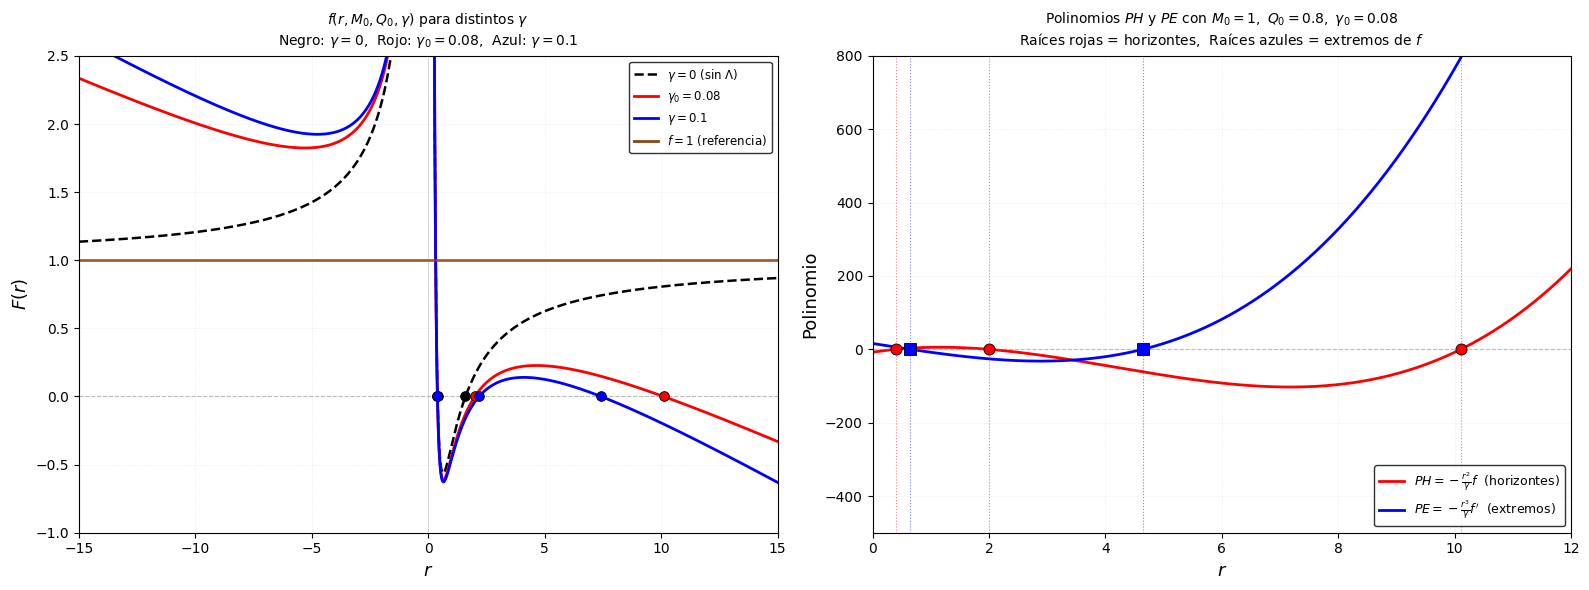

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros base ──────────────────────────────────────────────────────────
M0 = 1.0
Q0 = 0.8
g0 = 0.08

# ─── Funciones ───────────────────────────────────────────────────────────────
def f(r, M, Q, g):
    return 1 - 2*M/r + Q**2/r**2 - g*r

def fp(r, M, Q, g):
    return 2*M/r**2 - 2*Q**2/r**3 - g

def PH(r, M, Q, g):
    return r**3 - r**2/g + 2*M*r/g - Q**2/g

def PE(r, M, Q, g):
    return r**3 + 2*Q**2/g - 2*M*r/g

# ─── Dominio (incluyendo r < 0 como el notebook) ──────────────────────────────
r_neg = np.linspace(-15, -0.01, 5000)   # rama negativa
r_pos = np.linspace( 0.01, 15,  5000)   # rama positiva

# ─── Figura ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 1 — Reproducción exacta del gráfico del notebook
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[0]
ax.set_facecolor('white')

for rdom, ls_neg in [(r_neg, '-'), (r_pos, '-')]:
    ax.plot(rdom, f(rdom, M0, Q0, 0),   color='black', lw=1.8,
            ls='--' if rdom is r_pos else '--')
    ax.plot(rdom, f(rdom, M0, Q0, g0),  color='red',   lw=2.0)
    ax.plot(rdom, f(rdom, M0, Q0, 0.1), color='blue',  lw=2.0)

# Línea f=1 (referencia marrón)
ax.axhline(1, color='#8B4513', lw=2.0, alpha=0.85)
ax.axhline(0, color='gray',    lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='gray',    lw=0.5, alpha=0.4)

# Marcadores en los horizontes
# gamma=0: r=0.4, r=1.6
for rv in [0.4, 1.6]:
    ax.plot(rv, 0, 'o', color='black', ms=7, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)

# gamma=0.08: r=0.395878, r=2, r=10.1041
for rv in [0.395878, 2.0, 10.1041]:
    ax.plot(rv, 0, 'o', color='red', ms=7, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)

# gamma=0.1
import numpy.polynomial.polynomial as poly
roots_01 = np.roots([-0.1, 1, -2*M0, Q0**2])
roots_01 = np.sort(np.real(roots_01[np.abs(np.imag(roots_01)) < 1e-8]))
for rv in roots_01:
    ax.plot(rv, 0, 'o', color='blue', ms=7, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)

ax.set_xlim(-15, 15); ax.set_ylim(-1.0, 2.5)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('$F(r)$', fontsize=13)
ax.set_title(r'$f(r,M_0,Q_0,\gamma)$ para distintos $\gamma$' + '\n'
             r'Negro: $\gamma=0$,  Rojo: $\gamma_0=0.08$,  Azul: $\gamma=0.1$',
             fontsize=10, pad=8)
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

# Leyenda manual
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], color='black', lw=1.8, ls='--', label=r'$\gamma=0$ (sin $\Lambda$)'),
    Line2D([0],[0], color='red',   lw=2.0,           label=r'$\gamma_0=0.08$'),
    Line2D([0],[0], color='blue',  lw=2.0,           label=r'$\gamma=0.1$'),
    Line2D([0],[0], color='#8B4513', lw=2.0,         label=r'$f=1$ (referencia)'),
]
ax.legend(handles=leyenda, fontsize=8.5, facecolor='white', edgecolor='black')

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 2 — Polinomios PH y PE (zona r > 0)
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[1]
ax.set_facecolor('white')

r_p = np.linspace(0.01, 15, 8000)

ax.plot(r_p, PH(r_p, M0, Q0, g0), color='red',  lw=2.0,
        label=r'$PH = -\frac{r^2}{\gamma}f$  (horizontes)')
ax.plot(r_p, PE(r_p, M0, Q0, g0), color='blue', lw=2.0,
        label=r'$PE = -\frac{r^3}{\gamma}f^\prime$  (extremos)')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)

# Raíces de PH
for rv in [0.395878, 2.0, 10.1041]:
    ax.plot(rv, 0, 'o', color='red', ms=8, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)
    ax.axvline(rv, color='red', lw=0.8, ls=':', alpha=0.5)

# Raíces de PE (extremos de f)
pe_roots = np.roots([1, 0, -2*M0/g0, 2*Q0**2/g0])
pe_roots = np.sort(np.real(pe_roots[np.abs(np.imag(pe_roots)) < 1e-8]))
pe_roots = pe_roots[pe_roots > 0]
for rv in pe_roots:
    ax.plot(rv, 0, 's', color='blue', ms=8, zorder=6,
            markeredgecolor='black', markeredgewidth=0.6)
    ax.axvline(rv, color='blue', lw=0.8, ls=':', alpha=0.5)

ax.set_xlim(0, 12); ax.set_ylim(-500, 800)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('Polinomio', fontsize=13)
ax.set_title(r'Polinomios $PH$ y $PE$ con $M_0=1,\ Q_0=0.8,\ \gamma_0=0.08$'
             + '\nRaíces rojas = horizontes,  Raíces azules = extremos de $f$',
             fontsize=10, pad=8)
ax.legend(fontsize=9, facecolor='white', edgecolor='black')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('lapso_derivada_polinomios.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

# Potencial Fotones

$$V(r)=B(r)\frac{L^2}{r^2}=\left(1-\frac{2M}{r} + \frac{Q^2}{r^2}-\gamma r \right)\frac{L^2}{r^2}$$
$$= \frac{L^2}{r^2}-\frac{2ML^2}{r^3}+\frac{Q^2L^2}{r^4}-\gamma \frac{L^2}{r} $$

### Derivada de V(r)

$$V'(r)=L^2\left(-\frac{2}{r^3}+\frac{6M}{r^4}-\frac{4Q^2}{r^5}-\frac{\gamma}{r^2} \right) $$

### 2da derivada de V(r) y condición de estabilidad

$$V''(r)=\frac{6L^2}{r^4}-\frac{24 M L^2}{r^5}+\frac{20 Q^2L^2}{r^6}-\frac{2\gamma L^2}{r^3} $$

### Polinomio de órbitas $PU$ (órbitas circulares inestables)

$$V'(r)=0 | (-\frac{r^2}{\gamma L^2}) \ \ \Rightarrow \ \ \ PU(r)=r^3 - \frac{2}{\gamma}r^2 + \frac{6M}{\gamma}r - \frac{4Q^2}{\gamma} $$


rH=2.0000, rHH=10.1041
rU=0.5179, rU3=2.2268, rU1=-27.744782
rI=3.8364, rI3=33.0323, rI1=0.631287
E2U=-192.7809, E2I=1.4625


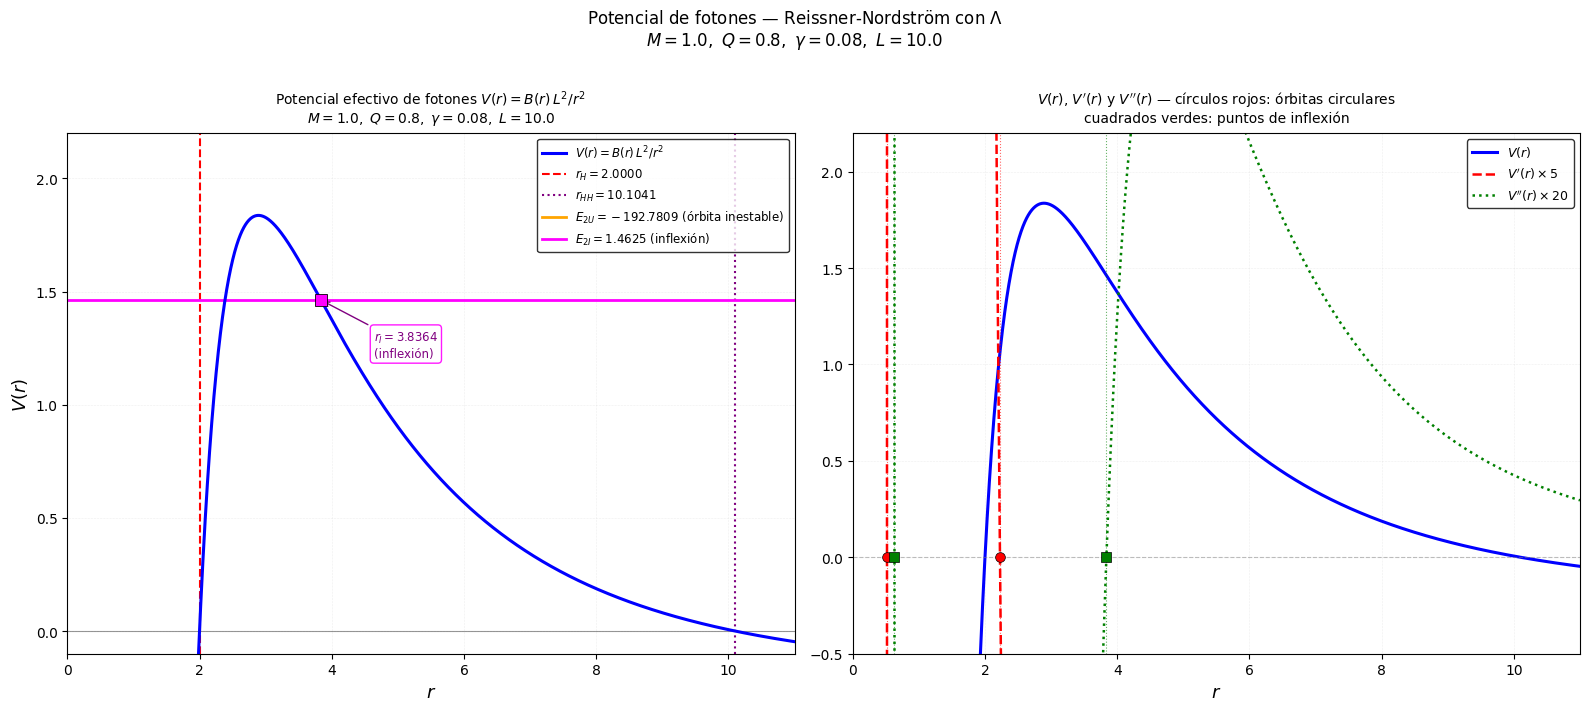

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros ───────────────────────────────────────────────────────────────
M0, Q0, g0, L = 1.0, 0.8, 0.08, 10.0

# ─── Funciones ────────────────────────────────────────────────────────────────
def B(r, M, Q, g):
    return 1 - 2*M/r + Q**2/r**2 - g*r

def V(r, M, Q, g, L):
    return B(r, M, Q, g) * L**2 / r**2

def Vp(r, M, Q, g, L):
    return L**2*(-2/r**3 + 6*M/r**4 - 4*Q**2/r**5 - g/r**2)

def Vpp(r, M, Q, g, L):
    return L**2*(6/r**4 - 24*M/r**5 + 20*Q**2/r**6 - 2*g/r**3)

# ─── Horizontes ───────────────────────────────────────────────────────────────
chi  = 2*np.sqrt(1-6*M0*g0)/(3*g0)
Xi   = (2-18*M0*g0+27*Q0**2*g0**2)/(2*(1-6*M0*g0)**1.5)
phi  = np.arccos(Xi)/3
rHH  = 1/(3*g0) + chi*np.cos(phi)
rH   = 1/(3*g0) + chi/2*(np.sqrt(3)*np.sin(phi)-np.cos(phi))
rC   = 1/(3*g0) - chi/2*(np.cos(phi)+np.sqrt(3)*np.sin(phi))

# ─── Raíces de V'=0 (órbitas circulares) ─────────────────────────────────────
roots_Vp  = np.sort(np.real(np.roots([-g0, -2, 6*M0, -4*Q0**2])))
rU1, rU, rU3 = roots_Vp

# ─── Raíces de V''=0 (puntos de inflexión) ───────────────────────────────────
roots_Vpp = np.sort(np.real(np.roots([-2*g0, 6, -24*M0, 20*Q0**2])))
rI1, rI, rI3 = roots_Vpp

# ─── Energías en las órbitas ──────────────────────────────────────────────────
E2U = V(rU,  M0, Q0, g0, L)
E2I = V(rI,  M0, Q0, g0, L)

print(f"rH={rH:.4f}, rHH={rHH:.4f}")
print(f"rU={rU:.4f}, rU3={rU3:.4f}, rU1={rU1:.6f}")
print(f"rI={rI:.4f}, rI3={rI3:.4f}, rI1={rI1:.6f}")
print(f"E2U={E2U:.4f}, E2I={E2I:.4f}")

# ─── Dominio ──────────────────────────────────────────────────────────────────
r = np.linspace(0.41, 11.0, 8000)
Vr = V(r, M0, Q0, g0, L)

# ─── Figura ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 1 — Potencial V(r) con líneas de energía 
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[0]
ax.set_facecolor('white')

# Potencial
ax.plot(r, Vr, color='blue', lw=2.2, label=r'$V(r) = B(r)\,L^2/r^2$', zorder=5)
ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.4)

# Horizontes (líneas verticales punteadas)
ax.axvline(rH,   color='red',    lw=1.5, ls='--',
           label=f'$r_H={rH:.4f}$')
ax.axvline(rHH,  color='purple', lw=1.5, ls=':',
           label=f'$r_{{HH}}={rHH:.4f}$')

# Energías (líneas horizontales)
ax.axhline(E2U, color='orange',  lw=2.0,
           label=f'$E_{{2U}}={E2U:.4f}$ (órbita inestable)')
ax.axhline(E2I, color='magenta', lw=2.0,
           label=f'$E_{{2I}}={E2I:.4f}$ (inflexión)')

# Marcadores en las órbitas
ax.plot(rU,  V(rU,  M0, Q0, g0, L), 'o', color='orange',  ms=9, zorder=7,
        markeredgecolor='black', markeredgewidth=0.6)
ax.plot(rI,  V(rI,  M0, Q0, g0, L), 's', color='magenta', ms=9, zorder=7,
        markeredgecolor='black', markeredgewidth=0.6)

# Anotaciones
ax.annotate(f'$r_U={rU:.4f}$\n(órbita inestable)',
            xy=(rU, E2U), xytext=(rU+0.8, E2U+0.15),
            fontsize=8.5, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='orange', alpha=0.9))

ax.annotate(f'$r_I={rI:.4f}$\n(inflexión)',
            xy=(rI, E2I), xytext=(rI+0.8, E2I-0.25),
            fontsize=8.5, color='purple',
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='magenta', alpha=0.9))

ax.set_xlim(0, 11); ax.set_ylim(-0.1, 2.2)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('$V(r)$', fontsize=13)
ax.set_title(r'Potencial efectivo de fotones $V(r) = B(r)\,L^2/r^2$'
             + f'\n$M={M0},\ Q={Q0},\ \\gamma={g0},\ L={L}$',
             fontsize=10, pad=8)
ax.legend(fontsize=8.5, facecolor='white', edgecolor='black', loc='upper right')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL 2 — V(r), V'(r), V''(r) normalizados
# ══════════════════════════════════════════════════════════════════════════════
ax = axes[1]
ax.set_facecolor('white')

r2   = np.linspace(0.41, 11.0, 8000)
Vr2  = V(r2,   M0, Q0, g0, L)
Vpr  = Vp(r2,  M0, Q0, g0, L)
Vppr = Vpp(r2, M0, Q0, g0, L)

ax.plot(r2, Vr2,        color='blue',  lw=2.2, label=r"$V(r)$")
ax.plot(r2, Vpr*5,      color='red',   lw=1.8, ls='--',
        label=r"$V'(r)\times 5$")
ax.plot(r2, Vppr*20,    color='green', lw=1.8, ls=':',
        label=r"$V''(r)\times 20$")
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)

# Raíces de V'
for rv in [rU1, rU, rU3]:
    if 0 < rv < 11:
        ax.axvline(rv, color='red', lw=0.8, ls=':', alpha=0.6)
        ax.plot(rv, 0, 'o', color='red', ms=7, zorder=6,
                markeredgecolor='black', markeredgewidth=0.5)

# Raíces de V''
for rv in [rI1, rI, rI3]:
    if 0 < rv < 11:
        ax.axvline(rv, color='green', lw=0.8, ls=':', alpha=0.6)
        ax.plot(rv, 0, 's', color='green', ms=7, zorder=6,
                markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlim(0, 11); ax.set_ylim(-0.5, 2.2)
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel('', fontsize=13)
ax.set_title(r"$V(r)$, $V'(r)$ y $V''(r)$ — círculos rojos: órbitas circulares"
             + '\ncuadrados verdes: puntos de inflexión',
             fontsize=10, pad=8)
ax.legend(fontsize=9, facecolor='white', edgecolor='black')
ax.grid(True, ls=':', lw=0.4, alpha=0.4)
ax.tick_params(labelsize=10)

fig.suptitle(r'Potencial de fotones — Reissner-Nordström con $\Lambda$'
             + f'\n$M={M0},\ Q={Q0},\ \\gamma={g0},\ L={L}$',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('potencial_fotones.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()